In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
TEST_SIZE = 0.25
N_FOLDS = 5
DATA_PATH = 'credit_data_sample.csv'


In [3]:
# =============================================================================
# STEP 1: LOAD DATA
# =============================================================================
def load_data(path):
    """Loads the credit dataset from CSV."""
    df = pd.read_csv(path)
    print(f"  Loaded {len(df):,} rows, {df.shape[1]} columns")
    print(f"  Default Rate: {df['default'].mean()*100:.2f}%")
    return df


In [4]:
# =============================================================================
# STEP 2: FEATURE ENGINEERING
# =============================================================================
def engineer_features(df):
    """
    Creates composite risk scores, interaction terms, and ratio features
    to improve model predictive power.
    """
    df = df.copy()

    # Income-based features
    df['income_per_account'] = df['annual_income'] / (df['num_credit_accounts'] + 1)
    df['income_to_debt_ratio'] = df['annual_income'] / (df['debt_to_income'] * df['annual_income'] + 1)

    # Credit behavior features
    df['credit_maturity'] = df['credit_history_length'] * df['num_credit_accounts']
    df['delinquency_rate'] = df['num_delinquencies_2y'] / (df['credit_history_length'] + 1)
    df['inquiry_intensity'] = df['num_hard_inquiries_6m'] / (df['credit_history_length'] + 1)

    # Risk composite scores
    df['debt_stress_score'] = (
        df['debt_to_income'] * 0.5 +
        df['credit_utilization'] * 0.3 +
        df['num_delinquencies_2y'] * 0.2
    )
    df['financial_stability'] = (
        np.log1p(df['annual_income']) * 0.3 +
        df['employment_years'] * 0.2 +
        df['credit_history_length'] * 0.2 +
        df['education_level'] * 0.3
    )

    # Interaction features
    df['age_income_interaction'] = df['age'] * np.log1p(df['annual_income'])
    df['dti_utilization_interaction'] = df['debt_to_income'] * df['credit_utilization']

    # Bucketed features
    df['income_tier'] = pd.qcut(df['annual_income'], q=5, labels=[1,2,3,4,5]).astype(int)
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], labels=[1,2,3,4,5]).astype(int)

    return df

In [5]:
# =============================================================================
# STEP 3: MODEL TRAINING & EVALUATION
# =============================================================================
def train_and_evaluate(X_train, X_test, y_train, y_test):
    """
    Trains multiple classification algorithms and evaluates using
    cross-validation and holdout test metrics.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=50, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_leaf=20,
            class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.8, random_state=RANDOM_SEED
        )
    }

    results = {}
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    print("\n" + "="*60)
    print("MODEL TRAINING & EVALUATION")
    print("="*60)

    for name, model in models.items():
        X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
        X_te = X_test_scaled if name == 'Logistic Regression' else X_test

        # Cross-validation
        cv_auc = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
        cv_f1 = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1')

        # Fit and predict
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Metrics
        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'y_prob': y_prob,
            'cv_auc_mean': cv_auc.mean(),
            'cv_auc_std': cv_auc.std(),
            'test_auc': roc_auc_score(y_test, y_prob),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'accuracy': accuracy_score(y_test, y_pred)
        }

        print(f"\n{name}:")
        print(f"  CV ROC-AUC:  {cv_auc.mean():.4f} (+/- {cv_auc.std()*2:.4f})")
        print(f"  Test ROC-AUC: {results[name]['test_auc']:.4f}")
        print(f"  Precision: {results[name]['precision']:.4f}")
        print(f"  Recall: {results[name]['recall']:.4f}")
        print(f"  F1-Score: {results[name]['f1']:.4f}")

    return results, scaler


In [6]:
# =============================================================================
# STEP 4: VISUALIZATION
# =============================================================================
def create_visualizations(results, X_test, y_test):
    """Generates publication-quality evaluation charts."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('Credit Scoring Model Evaluation Dashboard',
                 fontsize=18, fontweight='bold', y=0.98)

    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

    # 1. ROC Curves
    ax1 = axes[0, 0]
    for (name, color) in zip(results.keys(), colors):
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
        auc = results[name]['test_auc']
        ax1.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{name} (AUC = {auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves', fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # 2. Precision-Recall Curves
    ax2 = axes[0, 1]
    for (name, color) in zip(results.keys(), colors):
        precision_vals, recall_vals, _ = precision_recall_curve(
            y_test, results[name]['y_prob']
        )
        ax2.plot(recall_vals, precision_vals, color=color, lw=2.5, label=name)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curves', fontweight='bold')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)

    # 3. Metrics Comparison
    ax3 = axes[1, 0]
    metrics = ['Precision', 'Recall', 'F1-Score', 'Test ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.2
    for i, name in enumerate(results.keys()):
        values = [
            results[name]['precision'], results[name]['recall'],
            results[name]['f1'], results[name]['test_auc']
        ]
        ax3.bar(x + i*width, values, width, label=name,
               color=colors[i], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax3.set_ylabel('Score')
    ax3.set_title('Performance Metrics Comparison', fontweight='bold')
    ax3.set_xticks(x + width * 1.5)
    ax3.set_xticklabels(metrics)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.set_ylim(0, 1.0)
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Confusion Matrix (Best Model)
    ax4 = axes[1, 1]
    best_model = max(results, key=lambda x: results[x]['test_auc'])
    cm = confusion_matrix(y_test, results[best_model]['y_pred'])
    im = ax4.imshow(cm, interpolation='nearest', cmap='Blues')
    ax4.set_title(f'Confusion Matrix: {best_model}', fontweight='bold')
    ax4.set_xticks([0, 1])
    ax4.set_yticks([0, 1])
    ax4.set_xticklabels(['Non-Default', 'Default'])
    ax4.set_yticklabels(['Non-Default', 'Default'])
    ax4.set_xlabel('Predicted Label')
    ax4.set_ylabel('True Label')

    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            ax4.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('credit_model_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nChart saved: credit_model_evaluation.png")



CREDIT SCORING MODEL - INTERNSHIP PROJECT

[1/4] Loading dataset...
  Loaded 10,000 rows, 24 columns
  Default Rate: 4.45%

[2/4] Engineering features...
  Total features: 23

[3/4] Train/Test split: 7,500 / 2,500

[4/4] Training models...

MODEL TRAINING & EVALUATION

Logistic Regression:
  CV ROC-AUC:  0.7230 (+/- 0.0537)
  Test ROC-AUC: 0.7467
  Precision: 0.0888
  Recall: 0.6216
  F1-Score: 0.1554

Decision Tree:
  CV ROC-AUC:  0.6285 (+/- 0.0479)
  Test ROC-AUC: 0.6185
  Precision: 0.0624
  Recall: 0.4505
  F1-Score: 0.1096

Random Forest:
  CV ROC-AUC:  0.6978 (+/- 0.0823)
  Test ROC-AUC: 0.7245
  Precision: 0.1901
  Recall: 0.2072
  F1-Score: 0.1983

Gradient Boosting:
  CV ROC-AUC:  0.6664 (+/- 0.0727)
  Test ROC-AUC: 0.6973
  Precision: 0.2222
  Recall: 0.0360
  F1-Score: 0.0620

FINAL RANKING (by Test ROC-AUC)
1. Logistic Regression  | AUC: 0.7467 | F1: 0.1554 | Acc: 0.7000
2. Random Forest        | AUC: 0.7245 | F1: 0.1983 | Acc: 0.9256
3. Gradient Boosting    | AUC: 0.6973 

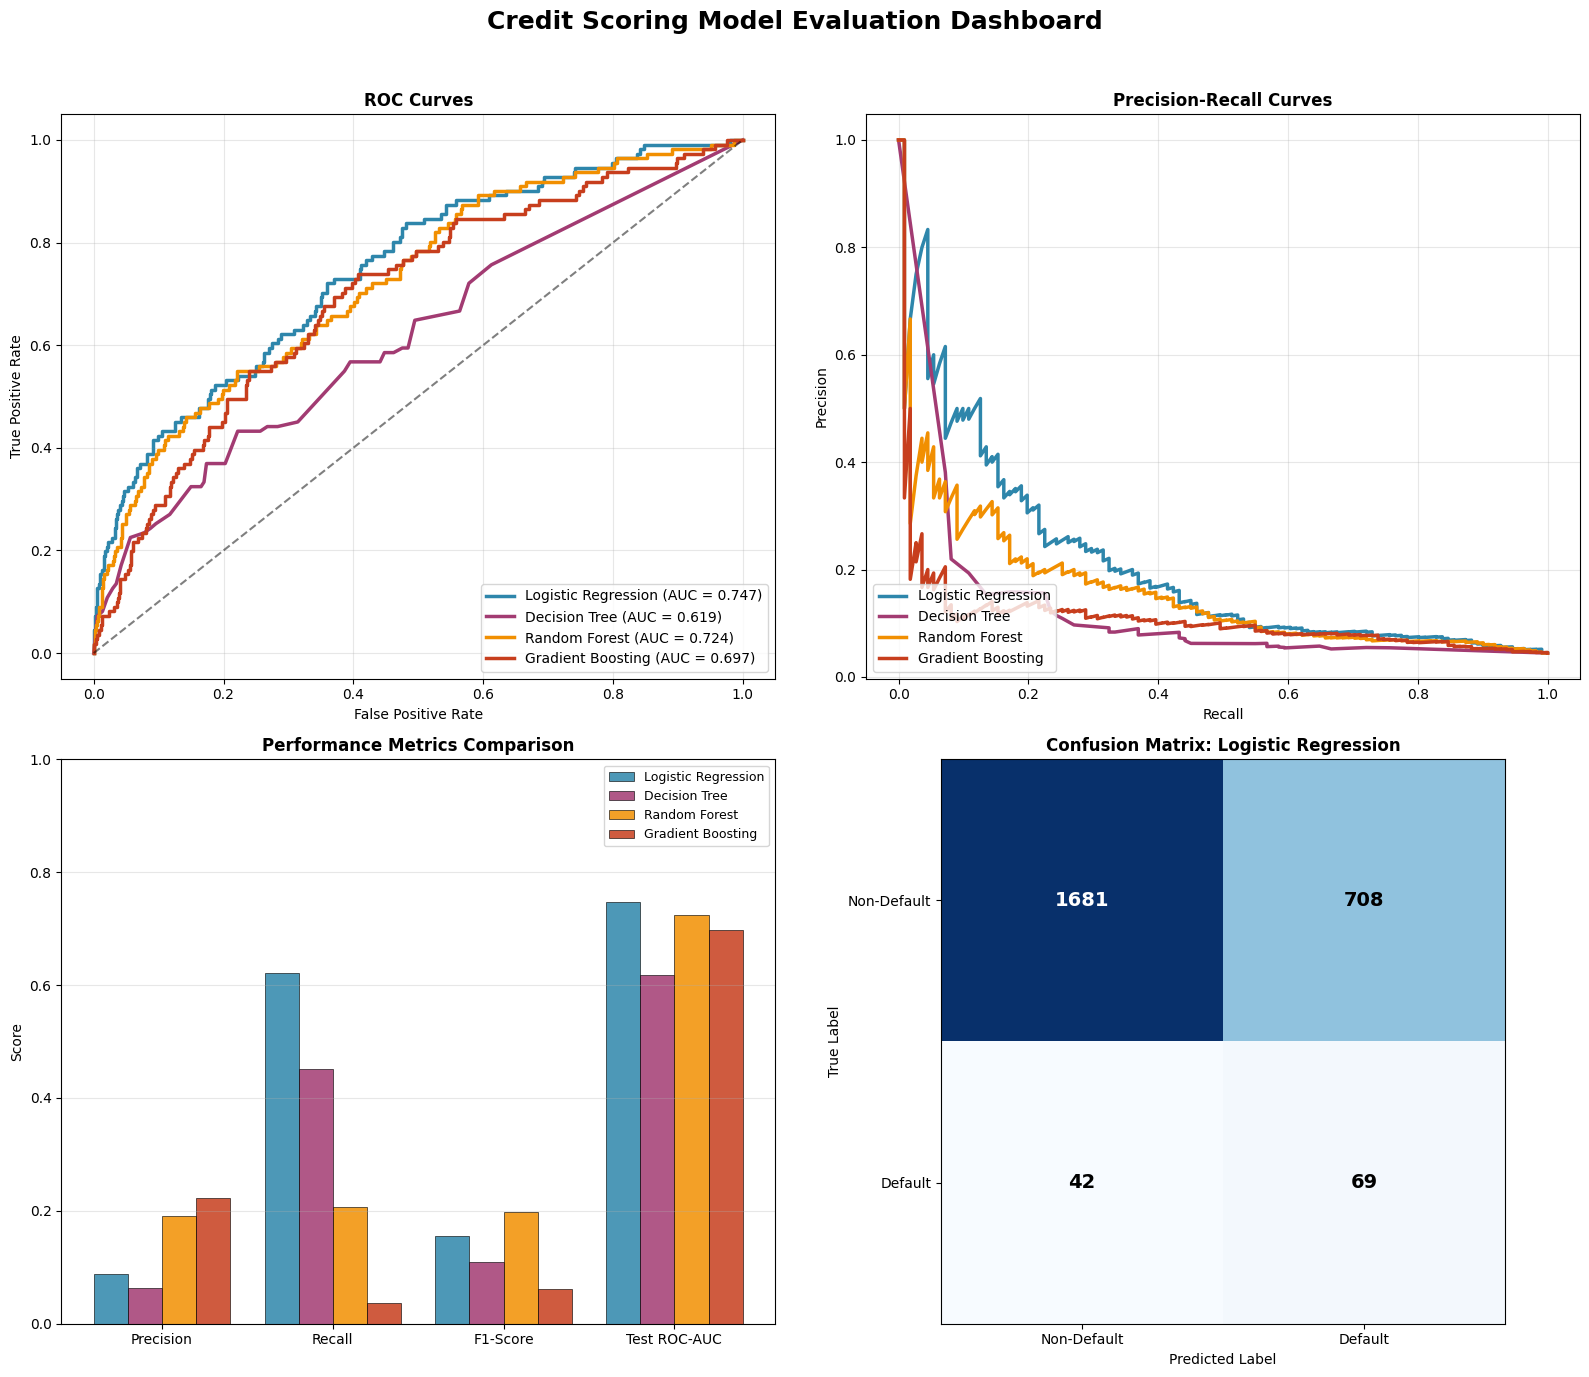


Chart saved: credit_model_evaluation.png

Detailed Report for Best Model (Logistic Regression):
------------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default     0.9756    0.7036    0.8176      2389
     Default     0.0888    0.6216    0.1554       111

    accuracy                         0.7000      2500
   macro avg     0.5322    0.6626    0.4865      2500
weighted avg     0.9362    0.7000    0.7882      2500


PROJECT COMPLETE


In [ ]:
if __name__ == "__main__":
    print("="*60)
    print("CREDIT SCORING MODEL - INTERNSHIP PROJECT")
    print("="*60)

    # Load data
    print("\n[1/4] Loading dataset...")
    df = load_data(DATA_PATH)

    # Feature engineering
    print("\n[2/4] Engineering features...")
    df = engineer_features(df)
    print(f"  Total features: {df.shape[1]-1}")

    # Split data
    X = df.drop('default', axis=1)
    y = df['default']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )
    print(f"\n[3/4] Train/Test split: {len(X_train):,} / {len(X_test):,}")

    # Train & evaluate
    print("\n[4/4] Training models...")
    results, scaler = train_and_evaluate(X_train, X_test, y_train, y_test)

    # Summary
    print("\n" + "="*60)
    print("FINAL RANKING (by Test ROC-AUC)")
    print("="*60)
    ranking = sorted(results.items(), key=lambda x: x[1]['test_auc'], reverse=True)
    for i, (name, res) in enumerate(ranking, 1):
        print(f"{i}. {name:20s} | AUC: {res['test_auc']:.4f} | "
              f"F1: {res['f1']:.4f} | Acc: {res['accuracy']:.4f}")

    # Visualizations
    print("\nGenerating visualizations...")
    create_visualizations(results, X_test, y_test)

    # Best model report
    best = ranking[0][0]
    print(f"\nDetailed Report for Best Model ({best}):")
    print("-"*60)
    print(classification_report(
        y_test, results[best]['y_pred'],
        target_names=['Non-Default', 'Default'], digits=4
    ))

    